In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as snsC

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix


**Load Data**

In [ ]:
# Google Sheet CSV export link
sheet_url = "https://docs.google.com/spreadsheets/d/11b7e1WbVFfN6O3nOR7EhHIbM7OTTY1O5IERVFHLFbd4/export?format=csv&gid=555652084"

# Read sheet directly into pandas
df = pd.read_csv(sheet_url)

# Preview
print(df.shape)
df.head()

(846, 25)


,name,file,transcript,text_length,age,gender,race,language,wps,readability,...,WX_WER,ZM_WER,BJ_WER,GM,YT,MS,FB,ZM,BJ,WX
0,Aaron Huey,AaronHuey_2010X,i m here today to show my photographs of the l...,2211,35.0,male,white,us,2.380,7.35,...,0.12489,0.06700,0.06335,i m here today to show my photographs of the l...,i m here today to show my photographs of the l...,i m here today to show my photographs of the l...,i m here today to show my photographs of the l...,i m here today to show my photographs of the l...,here today to show my photographs of the lakot...,hello i m here today to show my photographs of...
1,Abha Dawesar,AbhaDawesar_2013G,i was in new york during hurricane sandy and t...,1988,39.0,female,asian,l2,2.753,6.98,...,0.05989,0.04680,0.04076,i was in new york during hurricane sandy and t...,i was in new york during hurricane sandy and t...,i was in new york during hurricane sandy and t...,i was in new york during hurricane sandy and t...,i was in new york during hurricane sandy and t...,i was in new york during hurricane sandy and t...,hello i was in new york during hurricane sandy...
2,Abigail Marsh,AbigailMarsh_2016T,there s a man out there somewhere who looks a ...,2044,40.0,female,white,us,2.737,6.97,...,0.11373,0.05980,0.06667,there s a man out there somewhere who looks a ...,there s a man out there somewhere who looks a ...,there s a man out there somewhere who looks a ...,there s a man out there somewhere who looks a ...,there s a man out there somewhere who looks a ...,here s a man out going somewhere who looks a l...,hello there s a man out there somewhere who lo...
3,Abraham Verghese,AbrahamVerghese_2011G,a few months ago a forty year old woman came t...,3084,56.0,male,asian,l2,2.767,6.94,...,0.09123,0.07103,0.07071,a few months ago a forty year old woman came t...,a few months ago a forty year old woman came t...,a few months ago a forty year old woman came t...,a few months ago a forty year old woman came t...,a few months ago a forty year old woman came t...,few months ago a forty year old woman came to ...,hello a few months ago a forty year old woman ...
4,Achenyo Idachaba,AchenyoIdachaba_2015W,welcome to bayeku a riverine community in ikor...,943,45.0,female,black,l2,2.133,7.64,...,0.17535,0.12752,0.09139,welcome to buyiku a riverine community in ikor...,welcome to bayeku a riverine community in ikor...,welcome to becu a riverine community in ecuado...,welcome to baiku a riverine community in ikoro...,welcome to baiku riverine community in icarudu...,welcome to baku a riverine community in ikorod...,welcome to river wind community in a vivid rep...


**Feature Engineering**

In [ ]:
wer_cols = ["YT_WER", "FB_WER", "MS_WER", "GM_WER", "WX_WER", "ZM_WER", "BJ_WER"]
df["avg_WER"] = df[wer_cols].mean(axis=1)



In [ ]:
df.groupby("race")["avg_WER"].mean()

,avg_WER
race,
asian,0.082609
black,0.087973
latino,0.087514
white,0.076225


*ASR systems transcribe White speakers’ speech most accurately and Black/Latino speakers least accurately.*         

This mirrors existing real-world findings where ASR systems trained primarily on White-dominated datasets struggle with other accents and dialects.

In [ ]:
df.groupby("gender")["avg_WER"].mean()


,avg_WER
gender,
female,0.068718
male,0.083458


*Male speakers face more transcription errors.*

This could be because of:
* Lower pitch variation (less expressive prosody),
* More background noise,
* Dataset imbalance (more male samples in training corpora).

This gender gap, though smaller than the racial gap, still shows performance disparity.

**Stance Classification Bias Analysis**

In [ ]:
!pip install transformers torch

In [ ]:
from transformers import pipeline
from sklearn.metrics import accuracy_score, confusion_matrix

**Initialize Zero-Shot Classifier**

In [ ]:
classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cpu


**Define Candidate Stance Labels**

In [ ]:
labels = ["support", "oppose", "neutral"]


**Define Helper Function**

In [ ]:
def get_stance(text):
    if pd.isna(text) or len(str(text).strip()) == 0:
        return None
    result = classifier(text, candidate_labels=labels)
    return result["labels"][0]  # Top predicted label


**Generate Stance Labels**

In [ ]:
import torch
from transformers import pipeline
from tqdm import tqdm
import pandas as pd # Assuming 'df' is a pandas DataFrame

# --- 0. Configuration for CPU Performance ---
# We are forcing CPU usage and using a model optimized for speed.
DEVICE = -1       # CPU is confirmed, so use -1
BATCH_SIZE = 32   # A moderate batch size for better CPU utilization
MAX_SEQ_LENGTH = 512 # Smaller max_length is often faster for smaller models

print(f"🐌 Running on CPU (device={DEVICE}). Using BATCH_SIZE={BATCH_SIZE}.")
print("✨ Switched to DistilBERT for a massive speed increase on CPU.")


# --- ✅ 1. Load Stance Classification Model (DistilBERT) ---
# Replacing BART-large-mnli with a faster, smaller DistilBERT-based model.
stance_classifier = pipeline(
    "text-classification",
    # 🌟 KEY CHANGE: Switched to a DistilBERT model for speed
    model="typeform/distilbert-base-uncased-mnli",
    device=DEVICE,
    truncation=True,
    max_length=MAX_SEQ_LENGTH
)


# --- ✅ 2. Helper function to safely batch texts ---
def batch_infer(texts):
    results = []
    for i in tqdm(range(0, len(texts), BATCH_SIZE)):
        # Truncate long texts manually before batching
        batch = [t[:2000] for t in texts[i:i + BATCH_SIZE]]

        # Classifier call using the configured max_length
        batch_results = stance_classifier(
            batch,
            truncation=True,
            max_length=MAX_SEQ_LENGTH
        )
        results.extend(batch_results)
    return results


# --- ✅ 3. Helper to extract labels ---
def get_labels(results):
    return [r["label"] for r in results]


# --- ✅ 4. Process the ground-truth transcripts ---
print("\n🔹 Processing stance labels for 'transcript' column...")
# Ensure 'df' is available and loaded with data
texts = df["transcript"].fillna("").tolist()
stance_true_results = batch_infer(texts)
df["stance_true"] = get_labels(stance_true_results)
print("✅ Done with transcript stance classification!")


# --- ✅ 5. Process each ASR model column ---
asr_columns = ["GM", "YT", "MS", "FB", "ZM", "BJ", "WX"]

for col in asr_columns:
    print(f"\n🔹 Processing ASR model: {col}...")
    texts = df[col].fillna("").tolist()
    stance_results = batch_infer(texts)
    df[f"stance_{col}"] = get_labels(stance_results)
    print(f"✅ Done: stance_{col}")

print("\n🎯 All stance labels generated successfully!")

🐌 Running on CPU (device=-1). Using BATCH_SIZE=32.
✨ Switched to DistilBERT for a massive speed increase on CPU.


config.json:   0%|          | 0.00/776 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/258 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

✅ Done: stance_ZM

🔹 Processing ASR model: BJ...


100%|██████████| 27/27 [09:01<00:00, 20.05s/it]


✅ Done: stance_BJ

🔹 Processing ASR model: WX...


100%|██████████| 27/27 [09:00<00:00, 20.02s/it]

✅ Done: stance_WX

🎯 All stance labels generated successfully!


**Labelled data to different csv file**

In [ ]:
df.to_csv("Labelled_data_stance_classification.csv", index=False)

NameError: name 'df' is not defined

**Load new csv**

In [ ]:
df = pd.read_csv("Labelled_data_stance_classification.csv")

In [ ]:
print(df.head)

<bound method NDFrame.head of                    name                     file  \
0            Aaron Huey          AaronHuey_2010X   
1          Abha Dawesar        AbhaDawesar_2013G   
2         Abigail Marsh       AbigailMarsh_2016T   
3      Abraham Verghese    AbrahamVerghese_2011G   
4      Achenyo Idachaba    AchenyoIdachaba_2015W   
..                  ...                      ...   
158  Christina Warinner  ChristinaWarinner_2012U   
159   Christine Sun Kim    ChristineSunKim_2015F   
160     Christoph Adami     ChristophAdami_2011X   
161    Christopher Bell    ChristopherBell_2015X   
162   Chrystia Freeland   ChrystiaFreeland_2013G   

                                            transcript  text_length   age  \
0    i m here today to show my photographs of the l...         2211  35.0   
1    i was in new york during hurricane sandy and t...         1988  39.0   
2    there s a man out there somewhere who looks a ...         2044  40.0   
3    a few months ago a forty year ol

In [ ]:
df.columns


Index(['name', 'file', 'transcript', 'text_length', 'age', 'gender', 'race',
       'language', 'wps', 'readability', 'f0mean', 'YT_WER', 'FB_WER',
       'MS_WER', 'GM_WER', 'WX_WER', 'ZM_WER', 'BJ_WER', 'GM', 'YT', 'MS',
       'FB', 'ZM', 'BJ', 'WX', 'avg_WER', 'stance_true', 'stance_GM',
       'stance_YT', 'stance_MS', 'stance_FB', 'stance_ZM', 'stance_BJ',
       'stance_WX'],
      dtype='object')

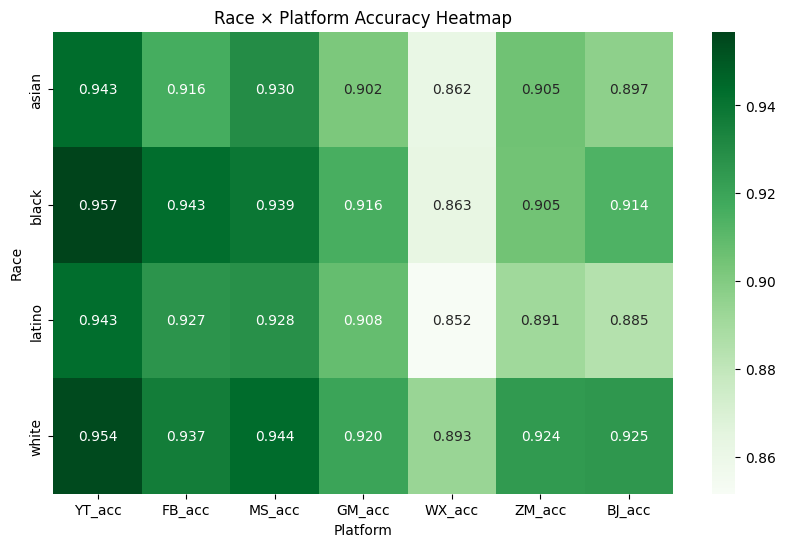

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Platforms
platforms = ['YT', 'FB', 'MS', 'GM', 'WX', 'ZM', 'BJ']

# 1) Convert WER → Accuracy
for p in platforms:
    df[p + '_acc'] = 1 - df[p + '_WER']

# 2) Accuracy columns
acc_cols = [p + '_acc' for p in platforms]

# 3) Race groups (only valid races)
race_groups = ['asian', 'black', 'latino', 'white']
df_race = df[df['race'].isin(race_groups)]

# 4) Race × Platform accuracy matrix
heatmap_matrix = df_race.groupby('race')[acc_cols].mean()

# 5) Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_matrix, annot=True, fmt=".3f", cmap="Greens")
plt.title("Race × Platform Accuracy Heatmap")
plt.xlabel("Platform")
plt.ylabel("Race")
plt.show()



=== Gender-wise stance accuracy ===
        stance_GM  stance_YT  stance_MS  stance_FB  stance_ZM  stance_BJ  \
male     0.709677   0.795699   0.774194   0.666667   0.602151   0.763441   
female   0.814286   0.814286   0.771429   0.771429   0.714286   0.814286   

        stance_WX  
male     0.580645  
female   0.685714  


<Figure size 1200x500 with 0 Axes>

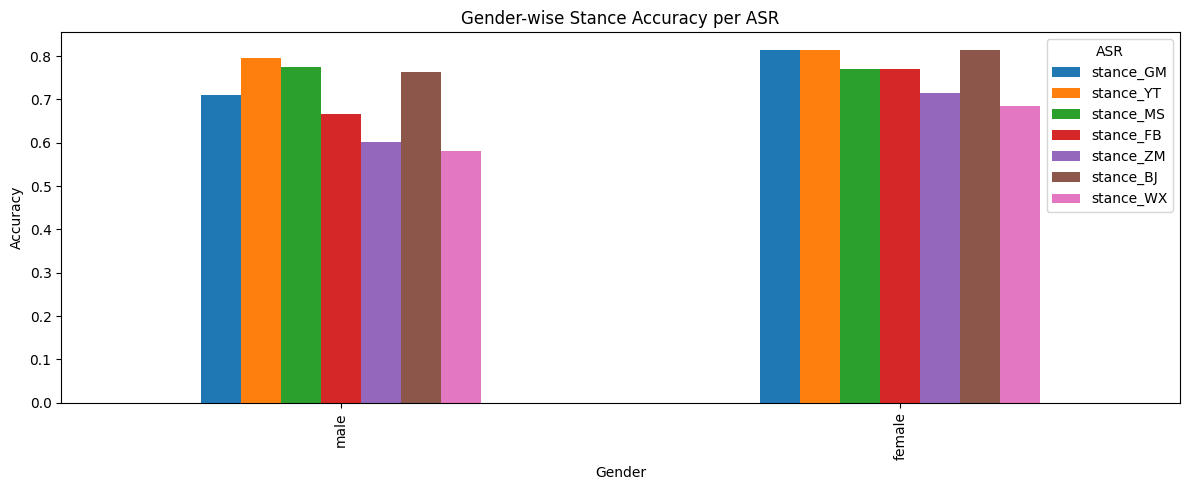


=== Race-wise stance accuracy ===
        stance_GM  stance_YT  stance_MS  stance_FB  stance_ZM  stance_BJ  \
white    0.735537   0.826446   0.768595   0.735537   0.644628   0.760331   
asian    0.791667   0.750000   0.833333   0.583333   0.791667   0.875000   
black    0.866667   0.800000   0.733333   0.733333   0.466667   0.866667   
latino   0.666667   0.333333   0.666667   0.666667   0.666667   0.666667   

        stance_WX  
white    0.611570  
asian    0.708333  
black    0.733333  
latino   0.000000  

=== Language-wise stance accuracy ===
        stance_GM  stance_YT  stance_MS  stance_FB  stance_ZM  stance_BJ  \
us       0.778947   0.821053   0.821053   0.757895   0.642105   0.800000   
l2       0.647059   0.676471   0.676471   0.500000   0.647059   0.735294   
non-us   0.794118   0.882353   0.735294   0.794118   0.676471   0.794118   

        stance_WX  
us       0.694737  
l2       0.441176  
non-us   0.617647  


<Figure size 1200x500 with 0 Axes>

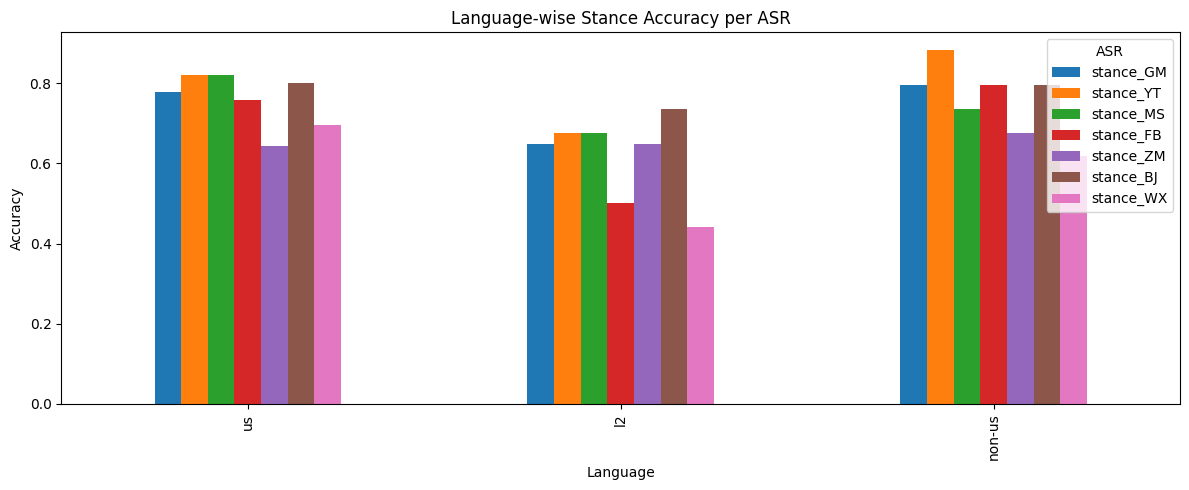

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ASR stance prediction columns
asr_cols = ['stance_GM', 'stance_YT', 'stance_MS',
            'stance_FB', 'stance_ZM', 'stance_BJ', 'stance_WX']

# Helper function: accuracy = mean of (prediction == true)
def compute_stance_accuracy(df, group_col):
    out = {}
    groups = df[group_col].dropna().unique()
    for g in groups:
        sub = df[df[group_col] == g]
        out[g] = {}
        for c in asr_cols:
            out[g][c] = (sub[c] == sub['stance_true']).mean()
    return pd.DataFrame(out).T


# ===============================
# 1) GENDER-WISE STANCE ACCURACY
# ===============================
gender_table = compute_stance_accuracy(df, 'gender')
print("\n=== Gender-wise stance accuracy ===")
print(gender_table)

plt.figure(figsize=(12, 5))
gender_table.plot(kind='bar', figsize=(12, 5), ylabel="Accuracy", xlabel="Gender", title="Gender-wise Stance Accuracy per ASR")
plt.legend(title="ASR")
plt.tight_layout()
plt.show()


# ===============================
# 2) RACE-WISE STANCE ACCURACY
# ===============================
race_table = compute_stance_accuracy(df, 'race')
print("\n=== Race-wise stance accuracy ===")
print(race_table)


# ===============================
# 3) LANGUAGE-WISE STANCE ACCURACY
# Categories: L2, non-us, us
# ===============================
# Fix language variations (lowercase, unify)
df['language'] = df['language'].str.lower()

language_table = compute_stance_accuracy(df, 'language')
print("\n=== Language-wise stance accuracy ===")
print(language_table)

plt.figure(figsize=(12, 5))
language_table.plot(kind='bar', figsize=(12, 5), ylabel="Accuracy", xlabel="Language", title="Language-wise Stance Accuracy per ASR")
plt.legend(title="ASR")
plt.tight_layout()
plt.show()


,ASR_Model,Accuracy,F1_Score
0,GM,0.725768,0.724794
1,YT,0.764775,0.764736
2,MS,0.756501,0.755840
3,FB,0.711584,0.710944
4,ZM,0.676123,0.674790
5,BJ,0.702128,0.701590
6,WX,0.617021,0.614881


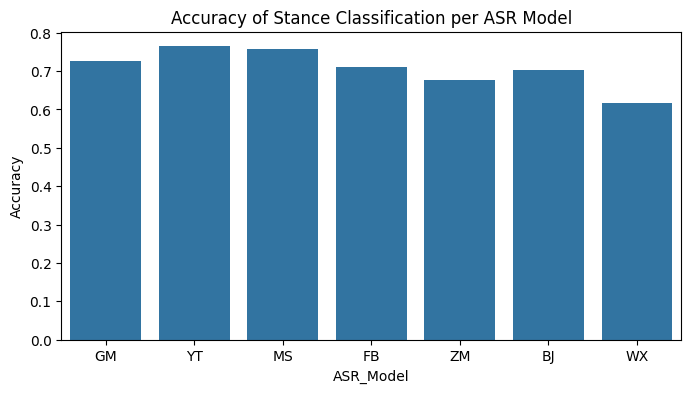

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ✅ List of ASR models
asr_columns = ["GM", "YT", "MS", "FB", "ZM", "BJ", "WX"]

# ✅ Store results
results = []

for col in asr_columns:
    y_true = df["stance_true"]
    y_pred = df[f"stance_{col}"]

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="weighted")

    results.append({
        "ASR_Model": col,
        "Accuracy": acc,
        "F1_Score": f1
    })

# ✅ Convert to DataFrame
stance_results_df = pd.DataFrame(results)
display(stance_results_df)

# ✅ Plot for better visualization
plt.figure(figsize=(8,4))
sns.barplot(data=stance_results_df, x="ASR_Model", y="Accuracy")
plt.title("Accuracy of Stance Classification per ASR Model")
plt.show()


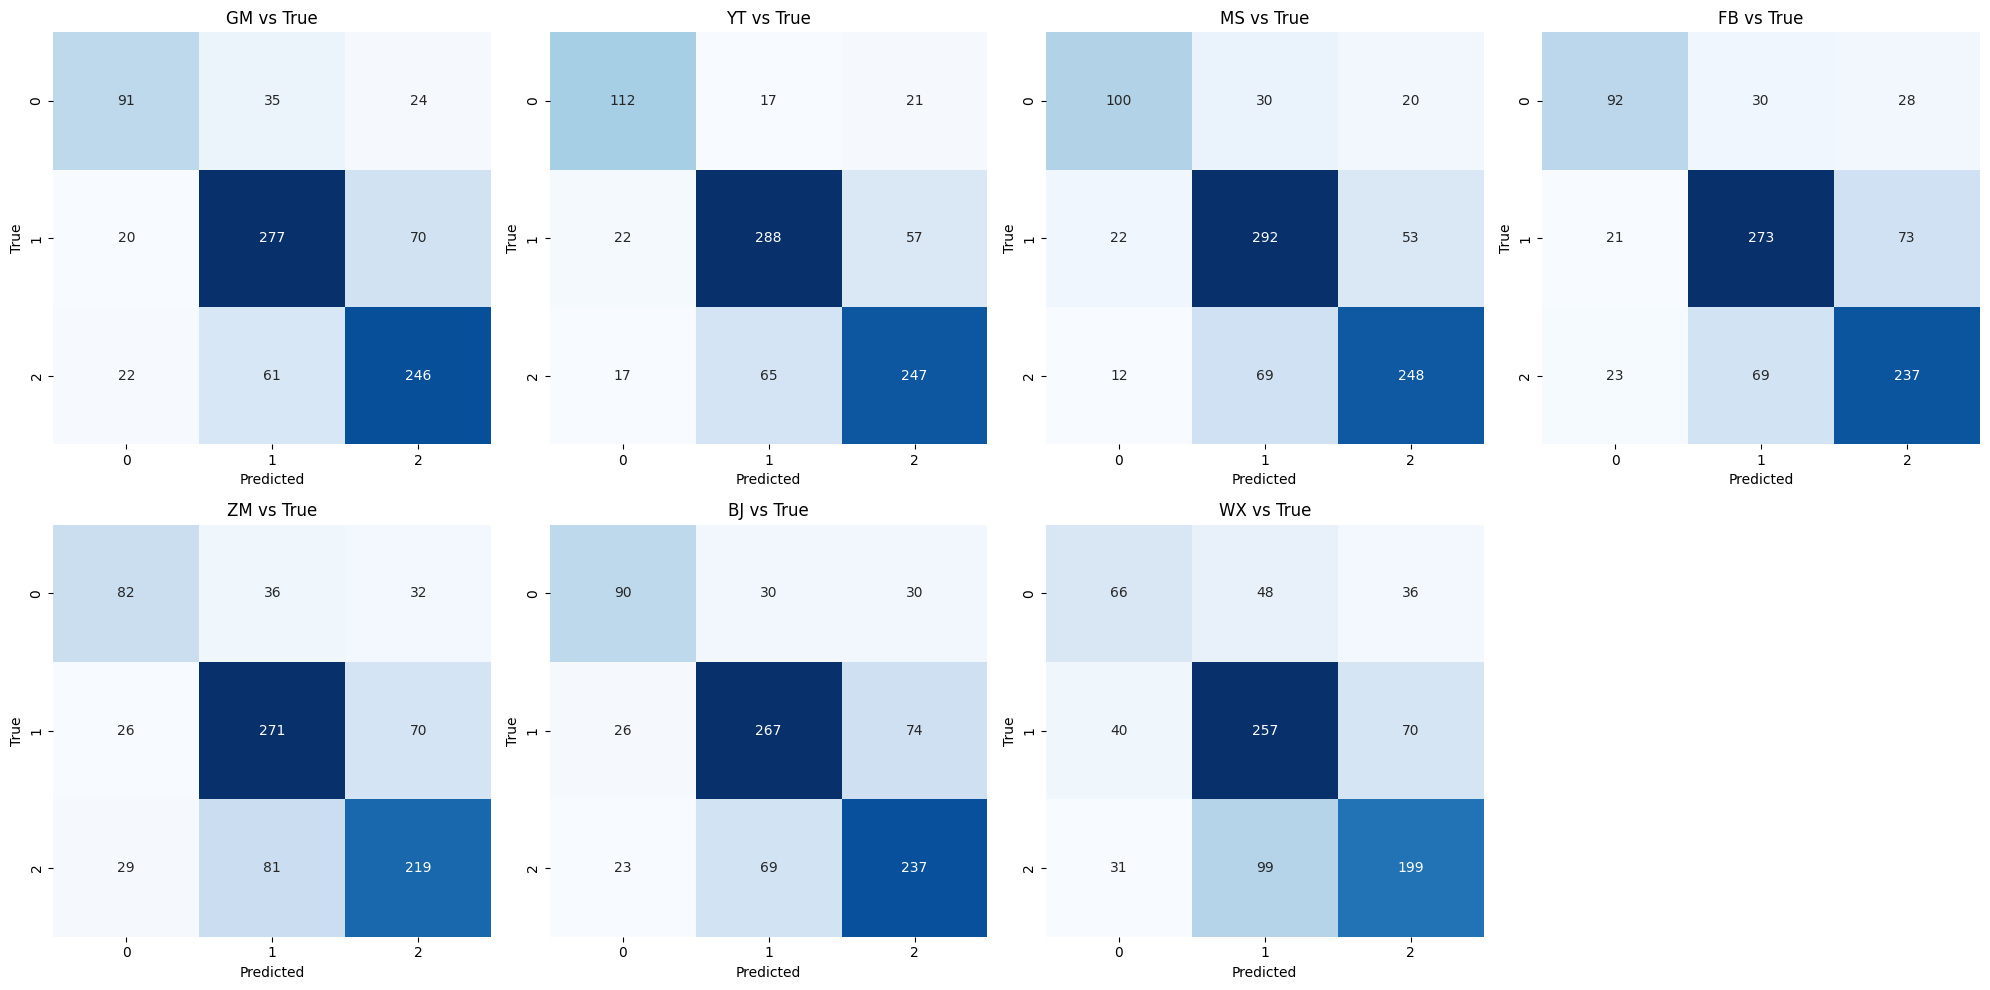


🔹 Classification Report: stance_true vs stance_GM
               precision    recall  f1-score   support

CONTRADICTION       0.68      0.61      0.64       150
   ENTAILMENT       0.74      0.75      0.75       367
      NEUTRAL       0.72      0.75      0.74       329

     accuracy                           0.73       846
    macro avg       0.72      0.70      0.71       846
 weighted avg       0.72      0.73      0.72       846


🔹 Classification Report: stance_true vs stance_YT
               precision    recall  f1-score   support

CONTRADICTION       0.74      0.75      0.74       150
   ENTAILMENT       0.78      0.78      0.78       367
      NEUTRAL       0.76      0.75      0.76       329

     accuracy                           0.76       846
    macro avg       0.76      0.76      0.76       846
 weighted avg       0.76      0.76      0.76       846


🔹 Classification Report: stance_true vs stance_MS
               precision    recall  f1-score   support

CONTRADICTION  

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, f1_score

# ASR model list
asr_models = ["GM", "YT", "MS", "FB", "ZM", "BJ", "WX"]

# Set up grid for side-by-side heatmaps (2 rows x 4 columns)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

# Dictionary to store F1-scores
f1_scores = {}

for i, model in enumerate(asr_models):
    y_true = df["stance_true"]
    y_pred = df[f"stance_{model}"]

    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # Plot heatmap
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[i], cbar=False)
    axes[i].set_title(f"{model} vs True")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("True")

    # Store weighted F1-score
    f1_scores[model] = f1_score(y_true, y_pred, average="weighted")

# Remove empty subplot if models < 8
for j in range(len(asr_models), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# --- Print classification reports ---
for model in asr_models:
    print(f"\n============================")
    print(f"🔹 Classification Report: stance_true vs stance_{model}")
    print("============================")
    print(classification_report(df["stance_true"], df[f"stance_{model}"]))

# --- Print overall F1-score summary ---
print("\n📊 Weighted F1-scores per model:")
for model, score in f1_scores.items():
    print(f"{model}: {score:.4f}")


In [ ]:
from scipy.stats import pearsonr

for col in asr_columns:
    stance_match = (df["stance_true"] == df[f"stance_{col}"]).astype(int)
    correlation, _ = pearsonr(df[col + "_WER"], stance_match)
    print(f"{col} correlation between WER and stance accuracy: {correlation:.3f}")


GM correlation between WER and stance accuracy: -0.029
YT correlation between WER and stance accuracy: -0.132
MS correlation between WER and stance accuracy: -0.120
FB correlation between WER and stance accuracy: -0.101
ZM correlation between WER and stance accuracy: -0.097
BJ correlation between WER and stance accuracy: -0.067
WX correlation between WER and stance accuracy: -0.128


In [ ]:
asr_models = ["GM", "YT", "MS", "FB", "ZM", "BJ", "WX"]

for model in asr_models:
    df[f"stance_match_{model}"] = (df["stance_true"] == df[f"stance_{model}"]).astype(int)


**Gender-based Analysis**

In [ ]:
print("=== Gender-based stance accuracy ===")
for model in asr_models:
    print(f"\nModel: {model}")
    print(df.groupby("gender")[f"stance_match_{model}"].mean())


=== Gender-based stance accuracy ===

Model: GM
gender
female    0.734899
male      0.720803
Name: stance_match_GM, dtype: float64

Model: YT
gender
female    0.795302
male      0.748175
Name: stance_match_YT, dtype: float64

Model: MS
gender
female    0.798658
male      0.733577
Name: stance_match_MS, dtype: float64

Model: FB
gender
female    0.755034
male      0.687956
Name: stance_match_FB, dtype: float64

Model: ZM
gender
female    0.728188
male      0.647810
Name: stance_match_ZM, dtype: float64

Model: BJ
gender
female    0.714765
male      0.695255
Name: stance_match_BJ, dtype: float64

Model: WX
gender
female    0.627517
male      0.611314
Name: stance_match_WX, dtype: float64


**Race-based Analysis**

In [ ]:
print("\n=== Race-based stance accuracy ===")
for model in asr_models:
    print(f"\nModel: {model}")
    print(df.groupby("race")[f"stance_match_{model}"].mean())



=== Race-based stance accuracy ===

Model: GM
race
asian     0.778846
black     0.792208
latino    0.857143
white     0.706605
Name: stance_match_GM, dtype: float64

Model: YT
race
asian     0.769231
black     0.805195
latino    0.642857
white     0.761905
Name: stance_match_YT, dtype: float64

Model: MS
race
asian     0.788462
black     0.779221
latino    0.785714
white     0.748080
Name: stance_match_MS, dtype: float64

Model: FB
race
asian     0.730769
black     0.727273
latino    0.785714
white     0.705069
Name: stance_match_FB, dtype: float64

Model: ZM
race
asian     0.711538
black     0.636364
latino    0.785714
white     0.672811
Name: stance_match_ZM, dtype: float64

Model: BJ
race
asian     0.740385
black     0.740260
latino    0.785714
white     0.689708
Name: stance_match_BJ, dtype: float64

Model: WX
race
asian     0.644231
black     0.688312
latino    0.714286
white     0.602151
Name: stance_match_WX, dtype: float64


**Language-based Analysis**

In [ ]:
print("\n=== Language-based stance accuracy ===")
for model in asr_models:
    print(f"\nModel: {model}")
    print(df.groupby("language")[f"stance_match_{model}"].mean())



=== Language-based stance accuracy ===

Model: GM
language
l2        0.730263
non-us    0.712963
us        0.730126
Name: stance_match_GM, dtype: float64

Model: YT
language
l2        0.730263
non-us    0.759259
us        0.778243
Name: stance_match_YT, dtype: float64

Model: MS
language
l2        0.730263
non-us    0.708333
us        0.786611
Name: stance_match_MS, dtype: float64

Model: FB
language
l2        0.664474
non-us    0.722222
us        0.721757
Name: stance_match_FB, dtype: float64

Model: ZM
language
l2        0.677632
non-us    0.648148
us        0.688285
Name: stance_match_ZM, dtype: float64

Model: BJ
language
l2        0.717105
non-us    0.662037
us        0.715481
Name: stance_match_BJ, dtype: float64

Model: WX
language
l2        0.611842
non-us    0.587963
us        0.631799
Name: stance_match_WX, dtype: float64


**WPS (Words Per Second) Group-based Analysis**

---



In [ ]:
df["wps_group"] = pd.qcut(df["wps"], 4, labels=["Slow", "Moderate", "Fast", "Very Fast"])

print("\n=== WPS (speed)-based stance accuracy ===")
for model in asr_models:
    print(f"\nModel: {model}")
    print(df.groupby("wps_group")[f"stance_match_{model}"].mean())



=== WPS (speed)-based stance accuracy ===

Model: GM
wps_group
Slow         0.735849
Moderate     0.747664
Fast         0.703349
Very Fast    0.715640
Name: stance_match_GM, dtype: float64

Model: YT
wps_group
Slow         0.816038
Moderate     0.775701
Fast         0.760766
Very Fast    0.706161
Name: stance_match_YT, dtype: float64

Model: MS
wps_group
Slow         0.787736
Moderate     0.738318
Fast         0.741627
Very Fast    0.758294
Name: stance_match_MS, dtype: float64

Model: FB
wps_group
Slow         0.702830
Moderate     0.724299
Fast         0.708134
Very Fast    0.710900
Name: stance_match_FB, dtype: float64

Model: ZM
wps_group
Slow         0.669811
Moderate     0.700935
Fast         0.641148
Very Fast    0.691943
Name: stance_match_ZM, dtype: float64

Model: BJ
wps_group
Slow         0.688679
Moderate     0.738318
Fast         0.684211
Very Fast    0.696682
Name: stance_match_BJ, dtype: float64

Model: WX
wps_group
Slow         0.646226
Moderate     0.616822
Fast      

/tmp/ipython-input-248684323.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby("wps_group")[f"stance_match_{model}"].mean())


**Readability-based Analysis**

In [ ]:
df["readability_group"] = pd.qcut(df["readability"], 4, labels=["Low", "Medium", "High", "Very High"])

print("\n=== Readability-based stance accuracy ===")
for model in asr_models:
    print(f"\nModel: {model}")
    print(df.groupby("readability_group")[f"stance_match_{model}"].mean())



=== Readability-based stance accuracy ===

Model: GM
readability_group
Low          0.706977
Medium       0.690141
High         0.747619
Very High    0.759615
Name: stance_match_GM, dtype: float64

Model: YT
readability_group
Low          0.720930
Medium       0.751174
High         0.785714
Very High    0.802885
Name: stance_match_YT, dtype: float64

Model: MS
readability_group
Low          0.772093
Medium       0.732394
High         0.761905
Very High    0.759615
Name: stance_match_MS, dtype: float64

Model: FB
readability_group
Low          0.697674
Medium       0.694836
High         0.700000
Very High    0.754808
Name: stance_match_FB, dtype: float64

Model: ZM
readability_group
Low          0.665116
Medium       0.643192
High         0.690476
Very High    0.706731
Name: stance_match_ZM, dtype: float64

Model: BJ
readability_group
Low          0.697674
Medium       0.704225
High         0.704762
Very High    0.701923
Name: stance_match_BJ, dtype: float64

Model: WX
readability_grou

/tmp/ipython-input-430072464.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby("readability_group")[f"stance_match_{model}"].mean())


**Intersectional Bias**

In [ ]:
print("\n=== Intersectional (Gender × Race) stance accuracy ===")
for model in asr_models:
    print(f"\nModel: {model}")
    print(df.groupby(["gender", "race"])[f"stance_match_{model}"].mean())



=== Intersectional (Gender × Race) stance accuracy ===

Model: GM
gender  race  
female  asian     0.804348
        black     0.772727
        latino    0.750000
        white     0.710000
male    asian     0.758621
        black     0.818182
        latino    1.000000
        white     0.705100
Name: stance_match_GM, dtype: float64

Model: YT
gender  race  
female  asian     0.739130
        black     0.818182
        latino    0.625000
        white     0.810000
male    asian     0.793103
        black     0.787879
        latino    0.666667
        white     0.740576
Name: stance_match_YT, dtype: float64

Model: MS
gender  race  
female  asian     0.760870
        black     0.795455
        latino    0.750000
        white     0.810000
male    asian     0.810345
        black     0.757576
        latino    0.833333
        white     0.720621
Name: stance_match_MS, dtype: float64

Model: FB
gender  race  
female  asian     0.826087
        black     0.750000
        latino    0.7500

**Compare actual vs predicted stance**

In [ ]:
for model in ["GM", "YT", "FB", "MS", "ZM", "BJ", "WX"]:
    df[f"stance_match_{model}"] = (df["stance_true"] == df[f"stance_{model}"]).astype(int)
    acc = df[f"stance_match_{model}"].mean()
    print(f"{model} stance accuracy: {acc:.3f}")


GM stance accuracy: 0.726
YT stance accuracy: 0.765
FB stance accuracy: 0.712
MS stance accuracy: 0.757
ZM stance accuracy: 0.676
BJ stance accuracy: 0.702
WX stance accuracy: 0.617


In [ ]:
key_asr_platforms = ["GM", "YT", "MS", "FB", "ZM", "BJ", "WX"]


In [ ]:
# ---------------------------------------------------------
# FIX: Create flip columns + define ASR platforms
# ---------------------------------------------------------

asr_models = ["GM", "YT", "MS", "FB", "ZM", "BJ", "WX"]

# 1. Create flip columns: 1 = stance changed, 0 = no change
for m in asr_models:
    df[f"{m}_flip"] = 1 - df[f"stance_match_{m}"]

# 2. Define key_asr_platforms for flip rate computation
key_asr_platforms = asr_models



DEMOGRAPHIC IMPACT ANALYSIS

📊 GENDER ANALYSIS:
  female: 0.264 avg flip rate (n=298.0)
  male: 0.308 avg flip rate (n=548.0)

🌍 RACE ANALYSIS:
  asian: 0.262 avg flip rate (n=104.0)
  black: 0.262 avg flip rate (n=77.0)
  latino: 0.235 avg flip rate (n=14.0)
  white: 0.302 avg flip rate (n=651.0)

🗣️ LANGUAGE ANALYSIS:
  l2: 0.305 avg flip rate (n=152.0)
  non-us: 0.314 avg flip rate (n=216.0)
  us: 0.278 avg flip rate (n=478.0)


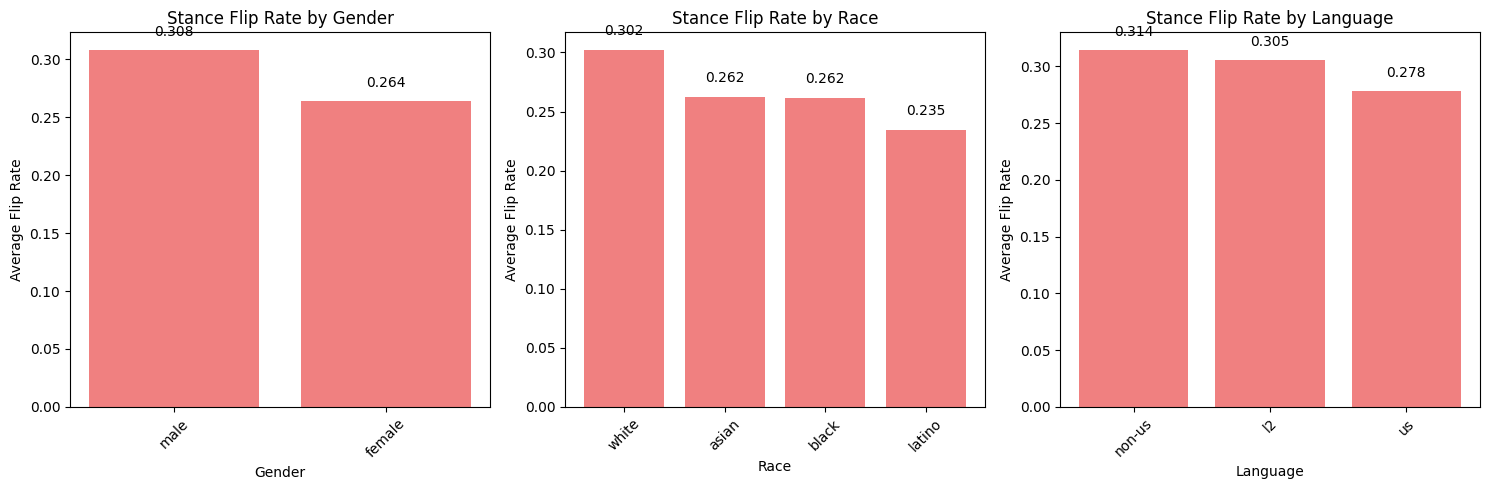

In [ ]:
# 2. Demographic impact analysis
print("\n" + "="*60)
print("DEMOGRAPHIC IMPACT ANALYSIS")
print("="*60)

# Calculate overall flip rates by demographic
df['total_flips'] = df[[f'{p}_flip' for p in key_asr_platforms]].sum(axis=1)
df['flip_rate'] = df['total_flips'] / len(key_asr_platforms)

# Gender analysis
if 'gender' in df.columns:
    print("\n📊 GENDER ANALYSIS:")
    gender_flip = df.groupby('gender')['flip_rate'].agg(['mean', 'count'])
    for gender, (flip_rate, count) in gender_flip.iterrows():
        print(f"  {gender}: {flip_rate:.3f} avg flip rate (n={count})")

# Race analysis
if 'race' in df.columns:
    print("\n🌍 RACE ANALYSIS:")
    race_flip = df.groupby('race')['flip_rate'].agg(['mean', 'count'])
    for race, (flip_rate, count) in race_flip.iterrows():
        print(f"  {race}: {flip_rate:.3f} avg flip rate (n={count})")

# Language analysis
if 'language' in df.columns:
    print("\n🗣️ LANGUAGE ANALYSIS:")
    language_flip = df.groupby('language')['flip_rate'].agg(['mean', 'count'])
    for language, (flip_rate, count) in language_flip.iterrows():
        print(f"  {language}: {flip_rate:.3f} avg flip rate (n={count})")

# Demographic visualization
demographic_cols = [col for col in ['gender', 'race', 'language'] if col in df.columns]
if demographic_cols:
    fig, axes = plt.subplots(1, len(demographic_cols), figsize=(5*len(demographic_cols), 5))

    if len(demographic_cols) == 1:
        axes = [axes]

    for i, demo_col in enumerate(demographic_cols):
        demo_data = df.groupby(demo_col)['flip_rate'].mean().sort_values(ascending=False)
        bars = axes[i].bar(range(len(demo_data)), demo_data.values, color='lightcoral')
        axes[i].set_title(f'Stance Flip Rate by {demo_col.title()}')
        axes[i].set_xlabel(demo_col.title())
        axes[i].set_ylabel('Average Flip Rate')
        axes[i].set_xticks(range(len(demo_data)))
        axes[i].set_xticklabels(demo_data.index, rotation=45)

        for j, (bar, rate) in enumerate(zip(bars, demo_data.values)):
            axes[i].text(j, bar.get_height() + 0.01, f'{rate:.3f}',
                         ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    plt.show()


In [ ]:
# ================================================
# FINAL CLEAN WORKING CODE (Laavanya v4 💚)
# ================================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.metrics import accuracy_score, f1_score

# ========= CREATE PDF FILE ==========
pdf = PdfPages("ASR_results_plots.pdf")

# ========= FIX STANCE COLUMNS (MAIN BUG FIX) ==========
stance_cols_all = [
    'stance_true', 'stance_GM', 'stance_YT', 'stance_MS',
    'stance_FB', 'stance_ZM', 'stance_BJ', 'stance_WX'
]

for col in stance_cols_all:
    df[col] = df[col].astype(str).str.strip().str.upper()


# ================================================
# 1) HEATMAP – Race × Platform Accuracy
# ================================================
platforms = ['YT', 'FB', 'MS', 'GM', 'WX', 'ZM', 'BJ']

for p in platforms:
    df[p + '_acc'] = 1 - df[p + '_WER']

acc_cols = [p + '_acc' for p in platforms]

race_groups = ['asian', 'black', 'latino', 'white']
df_race = df[df['race'].isin(race_groups)]

heatmap_matrix = df_race.groupby('race')[acc_cols].mean()

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_matrix, annot=True, fmt=".3f", cmap="Greens")
plt.title("Race × Platform Accuracy Heatmap")
plt.xlabel("Platform")
plt.ylabel("Race")
plt.tight_layout()
pdf.savefig(); plt.close()


# ================================================
# 2) FUNCTION: Compute Stance Accuracy
# ================================================
asr_cols = ['stance_GM', 'stance_YT', 'stance_MS',
            'stance_FB', 'stance_ZM', 'stance_BJ', 'stance_WX']

def compute_stance_accuracy(df, group_col):
    out = {}
    groups = df[group_col].dropna().unique()
    for g in groups:
        sub = df[df[group_col] == g]
        out[g] = {}
        for c in asr_cols:
            out[g][c] = (sub[c] == sub['stance_true']).mean()
    return pd.DataFrame(out).T


# ================================================
# 3) GENDER-WISE STANCE ACCURACY (PLOT)
# ================================================
gender_table = compute_stance_accuracy(df, 'gender')

plt.figure(figsize=(12, 5))
ax = gender_table.plot(
    kind='bar',
    ylabel="Accuracy",
    xlabel="Gender",
    title="Gender-wise Stance Accuracy per ASR",
    figsize=(12, 5)
)
plt.legend(title="ASR", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
pdf.savefig(); plt.close()


# ================================================
# 4) RACE-WISE STANCE ACCURACY (TABLE ONLY)
# ================================================
race_table = compute_stance_accuracy(df, 'race')
print("\nRace Table:\n", race_table)


# ================================================
# 5) LANGUAGE-WISE STANCE ACCURACY (PLOT) — FIXED
# ================================================
df['language'] = df['language'].str.lower()

language_table = compute_stance_accuracy(df, 'language')

# Fixed language order
order = ['l2', 'us', 'non-us']
language_table = language_table.reindex(order)

plt.figure(figsize=(12, 6))
ax = language_table.plot(
    kind='bar',
    ylabel="Accuracy",
    xlabel="Language",
    title="Language-wise Stance Accuracy per ASR",
    figsize=(12, 6),
    width=0.75
)

plt.xticks(rotation=0)
plt.legend(title="ASR", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
pdf.savefig(); plt.close()


# ================================================
# 6) Stance Accuracy + F1 per ASR (PLOT)
# ================================================
asr_models = ["GM", "YT", "MS", "FB", "ZM", "BJ", "WX"]
results = []

for col in asr_models:
    y_true = df["stance_true"]
    y_pred = df[f"stance_{col}"]

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="weighted")

    results.append({
        "ASR_Model": col,
        "Accuracy": acc,
        "F1_Score": f1
    })

stance_results_df = pd.DataFrame(results)

plt.figure(figsize=(8,4))
sns.barplot(data=stance_results_df, x="ASR_Model", y="Accuracy")
plt.title("Accuracy of Stance Classification per ASR Model")
plt.tight_layout()
pdf.savefig(); plt.close()


# ================================================
# CLOSE PDF
# ================================================
pdf.close()

print("🎉 DONE! 'ASR_results_plots.pdf' CREATED SUCCESSFULLY ❤️")



Race Table:
         stance_GM  stance_YT  stance_MS  stance_FB  stance_ZM  stance_BJ  \
white    0.743802   0.834711   0.776860   0.743802   0.652893   0.768595   
asian    0.791667   0.750000   0.833333   0.583333   0.791667   0.875000   
black    0.866667   0.800000   0.733333   0.733333   0.466667   0.866667   
latino   0.666667   0.333333   0.666667   0.666667   0.666667   0.666667   

        stance_WX  
white    0.619835  
asian    0.708333  
black    0.733333  
latino   0.000000  
🎉 DONE! 'ASR_results_plots.pdf' CREATED SUCCESSFULLY ❤️


<Figure size 1200x500 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, f1_score
from matplotlib.backends.backend_pdf import PdfPages

asr_models = ["GM", "YT", "MS", "FB", "ZM", "BJ", "WX"]

# FIX: convert all stance columns to clean strings
df["stance_true"] = df["stance_true"].astype(str).str.strip().str.upper()

for m in asr_models:
    df[f"stance_{m}"] = df[f"stance_{m}"].astype(str).str.strip().str.upper()

pdf = PdfPages("stance_confusion_reports.pdf")
f1_scores = {}

# ============================================
# 1) HEATMAP PAGE
# ============================================

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, model in enumerate(asr_models):

    y_true = df["stance_true"]
    y_pred = df[f"stance_{model}"]

    cm = confusion_matrix(y_true, y_pred, labels=sorted(y_true.unique()))

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                ax=axes[i], cbar=False)
    axes[i].set_title(f"{model} vs True")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("True")

    f1_scores[model] = f1_score(y_true, y_pred, average="weighted")

for j in range(len(asr_models), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
pdf.savefig(fig)
plt.close()


# ============================================
# 2) CLASSIFICATION REPORT PAGE
# ============================================

fig2 = plt.figure(figsize=(8.5, 11))
text = ""

for model in asr_models:
    text += f"\n============================\n"
    text += f"Classification Report: stance_true vs stance_{model}\n"
    text += "============================\n"
    text += classification_report(
        df["stance_true"],
        df[f"stance_{model}"],
        digits=3
    ) + "\n"

fig2.text(0.01, 0.99, text, va='top', ha='left',
          fontsize=7, family="monospace")
pdf.savefig(fig2)
plt.close()


# ============================================
# 3) F1-SCORE SUMMARY PAGE
# ============================================

fig3 = plt.figure(figsize=(8.5, 11))
summary = "Weighted F1-score Summary\n\n"
for model, score in f1_scores.items():
    summary += f"{model}: {score:.4f}\n"

fig3.text(0.05, 0.95, summary, va='top', ha='left', fontsize=12)
pdf.savefig(fig3)
plt.close()

pdf.close()

print("PDF saved as stance_confusion_reports.pdf")


PDF saved as stance_confusion_reports.pdf
